## Section 1 — Library Imports

We import four categories of tools:

1. **Numerical core** (`numpy`): array math, random sampling.
2. **Plotting** (`matplotlib`): to visualize the synthetic data and, later, posteriors.
3. **`Eryn` components**: 
   - `EnsembleSampler`: the MCMC/RJ-MCMC engine that will explore parameter space *inside* each nested sampling iteration.
   - `State`: the container object Eryn uses to hold walker positions, `inds` (on/off masks for variable dimensionality), log-likelihoods, and log-priors simultaneously.
   - `uniform_dist`:" lets us define uniform prior distributions per-parameter, per-branch.
   - `GaussianMove`: a simple in-model proposal (small random-walk steps) used *between* trans-dimensional jumps.
3. **Progress bar** (`tqdm.trange`): nested sampling loops can run thousands of iterations; we want visual feedback.
4. **`corner`**: will be used in Section 10 for posterior corner plots — imported now so all imports live in one place.

We also fix `np.random.seed(...)` so that the synthetic data injection is **reproducible** — a core requirement for debugging Bayesian pipelines (if the data changes every run, you can't tell if a bug is in your sampler or just in stochastic variation).

In [16]:
# SECTION 1 — LIBRARY IMPORTS

import numpy as np                       # Core array / numerical operations
import matplotlib.pyplot as plt          # Plotting the data, injection, and later posteriors
from tqdm import trange                  # Progress bar for the (potentially long) nested sampling loop

# Eryn imports
from eryn.ensemble import EnsembleSampler    # The main sampler object: handles walkers, temperatures, RJ moves
from eryn.state import State                 # Container object: bundles coordinates + inds + log_like + log_prior
from eryn.prior import uniform_dist          # Defines a uniform prior distribution for one parameter
from eryn.moves import GaussianMove          # A small-step Gaussian random-walk proposal (in-model moves)

import corner                                # For posterior corner plots (used later, in post-processing)

# Reproducibility 
# Fixing the random seed means every time we re-run this notebook from the top,
# we get IDENTICAL synthetic data and identical random draws.
# This is essential for debugging: if our nested sampling evidence estimate
# changes between runs, you want to know it's due to the STOCHASTIC SAMPLER,
# not because the underlying "ground truth" data silently changed too.
np.random.seed(42)

## Section 2 — Toy Model Definition & Synthetic Data Generation

### The physical/statistical model

We model our 1D "signal" as a sum of $k$ Gaussian pulses over a time axis $t$:

$$
s(t) = \sum_{i=1}^{k} A_i \, \exp\!\left(-\frac{(t - \mu_i)^2}{2 \, c_{\text{fixed}}^2}\right)
$$

where, for pulse $i$:
- $A_i$ = **amplitude** (this thesis's Parameter 1 — will be sampled)
- $\mu_i$ = **mean position in time** (Parameter 2 — will be sampled)
- $c_{\text{fixed}}$ = **pulse width** (**fixed for ALL pulses, not sampled**)

### Why fix the width?

Model selection (deciding "how many pulses are present") is already a hard combinatorial + continuous problem. By fixing $c$, we:
1. Reduce the search space dimensionality per pulse (2 instead of 3) so faster RJ-MCMC mixing.
2. Remove a source of **parameter degeneracy**: in the 3-parameter version, a pulse can trade off amplitude vs. width (a tall-narrow pulse can mimic a short-wide one at fixed area), which makes the RJ acceptance ratio harder to reason about. Removing this degeneracy makes it much easier to verify, by eye, whether your Nested Sampling implementation is behaving correctly.

### Synthetic data / injection

We construct a ("injection") with a small number of pulses, add Gaussian measurement noise, and treat the resulting noisy time series as our "observed data." Because we *know* the true number of pulses and their true parameters, we can later check whether the sampler:
- Recovers the correct **posterior on the number of pulses** (model order),
- Recovers unbiased **posteriors on amplitude and mean position**.

observed_data already exists in memory — SKIPPING regeneration (delete the variable manually if you really want to resample noise).


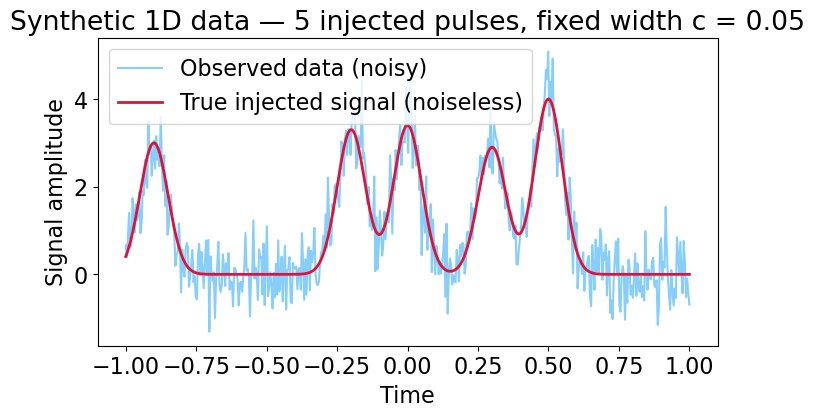

In [17]:
# SECTION 2 - TOY MODEL DIFINITON AND SYNTHETIC DATA GENERATION.

# 2.1 - Single pulse model

pulse_width = 0.05 # This is c in the Gaussin formula. It is identical for every pulse in the model

def single_gaussian_pulse(time_axis, amplitude, mean):
    pulse_values = amplitude * np.exp(-((time_axis - mean) ** 2) / (2 * pulse_width ** 2))
    return pulse_values

# 2.2 - Combine an arbitray number of pulses into one signal
"""
We need to do this because our model can contain multiple pulses simultaneously, 
and we need their total sum. We start with an 'empty canvas' of zeros and use a 
loop to calculate and add each pulse individually on top of the previous ones, 
building the final, unified signal that will be compared to our actual observations.
"""

def combine_all_pulses(time_axis, parameters):
    """
    Sums up an arbitrary number of Gaussian pulses to build the full noiseles
    model signal. This is the function that must handle a VARIABLE number of
    pulses — exactly the quantity our trans-dimensional sampler is trying to infer.

    time_axis : np.ndarray
    list_of_pulse_parameters : iterable of (amplitude, mean) pairs
        Each element describes ONE active pulse. 
    """
    # Example input for 'parameters': [[3.3, -0.2], [2.9, 0.3]] (A list containing 2 pulses)

    # Creates the empty canvas. If time_axis has 500 points, this makes: [0.0, 0.0, ..., 0.0]
    combined_signal = np.zeros_like(time_axis)
    
    # 1st round of loop: takes [3.3, -0.2]
    # 2nd round of loop: takes [2.9, 0.3]
    for single_pulse_parameters in parameters:
        
        # Unpacking the box: e.g., amplitude gets 3.3, mean gets -0.2
        amplitude, mean = single_pulse_parameters
        
        # Draws the pulse using 3.3 and -0.2, then adds it (+) to the existing combined_signal
        combined_signal += single_gaussian_pulse(time_axis, amplitude, mean)
        
    # After the loop finishes, returns the fully constructed waveform containing all pulses
    return combined_signal

# 2.3 Build the time axis
number_of_time_samples = 500
time_axis = np.linspace(-1,1,number_of_time_samples)

# 2.4 - Define the TRUE injected pulses
true_injected_pulse_parameters = [
    [3.3, -0.2],
    [3.4,  0.0],
    [2.9,  0.3],
    [4, 0.5],
    [3,-0.9]
]

true_number_of_pulses = len(true_injected_pulse_parameters)
noiseless_injected_signal = combine_all_pulses(time_axis, true_injected_pulse_parameters)

# 2.5 Add Gaussian measurement noise to build the "observed data"

noise_standard_deviation = 0.5

"""
WHY WE DO THIS:
If we didn't have this check, re-running this cell would create NEW random noise every single time.
This means our 'observed_data' would change behind our back, ruining our analysis.
"""

# Check if the variable 'observed_data' already exists in the notebook's memory (locals).
if 'observed_data' not in locals():

    
    # 1. Create the random noise (the "snow" on the signal)
    measurement_noise = noise_standard_deviation * np.random.randn(number_of_time_samples)
    
    # 2. Add the noise to our perfect, noiseless model to create the final fake data
    observed_data = noiseless_injected_signal + measurement_noise
    
    # 3. Print a message so we know it was successfully created
    print(f"Generated observed_data ONCE with seed 42. "
          f"True number of pulses = {true_number_of_pulses}.")

else:
    
    # -- THIS RUNS IF YOU ACCIDENTALLY (OR INTENTIONALLY) RE-RUN THE CELL --
    
    # The computer sees the data is already there, so it skips the random generation
    # and just prints this warning message instead.
    print("observed_data already exists in memory — SKIPPING regeneration "
          "(delete the variable manually if you really want to resample noise).")

# 2.6 — Visualize: does the noisy data plausibly hide the injected signal?

plt.figure(figsize=(8, 4))
plt.plot(time_axis, observed_data, color="lightskyblue", label="Observed data (noisy)")
plt.plot(time_axis, noiseless_injected_signal, color="crimson", lw=2, label="True injected signal (noiseless)")
plt.xlabel("Time")
plt.ylabel("Signal amplitude")
plt.title(f"Synthetic 1D data — {true_number_of_pulses} injected pulses, "
          f"fixed width c = {pulse_width}")
plt.legend()
plt.show()

## Section 3 — Prior Bounds & Prior Distribution Object

### What a "prior" means here

For each **active** pulse, we need a prior probability density over its 2 parameters:

$$
\pi(A_i, \mu_i) = \pi(A_i)\,\pi(\mu_i)
$$

We assume these are **independent uniform distributions**:
- $A_i \sim \mathcal{U}(A_{\min}, A_{\max})$ — amplitude is equally likely anywhere in a plausible range.
- $\mu_i \sim \mathcal{U}(t_{\min}, t_{\max})$ — the pulse center can be anywhere within the observed time window.

### Why `ProbDistContainer` and not a raw dict?

Eryn's `EnsembleSampler` expects `priors` to be a dictionary mapping **branch name - `ProbDistContainer` object**, not a bare dictionary of `uniform_dist` objects. The `ProbDistContainer`:
- Wraps a `{parameter_index: distribution}` mapping into ONE object.
- Supplies `.rvs(size=...)` - draws random samples for **initializing walkers** (Section 6).
- Supplies `.logpdf(x)` - evaluates $\log \pi(x)$, which Eryn calls internally every time it needs the prior probability of a proposed point (both in-model Gaussian moves and RJ birth/death moves).

Without wrapping it this way, Eryn has no consistent interface to sample from or evaluate the prior for a variable, dictionary-based, multi-leaf parameter space.

### Parameter indexing convention

Inside the `"gauss"` branch, we use **integer keys** `0` and `1` to label which prior goes with which column of the `(..., ndim)` coordinate array:
- key `0` - amplitude (column 0)
- key `1` - mean position (column 1)

This ordering MUST exactly match the order you unpack parameters in `single_gaussian_pulse` (Section 2) and in the log-likelihood function (Section 4) — a mismatch here is one of the most common silent bugs in Eryn projects (e.g., accidentally treating amplitude values as time positions).

In [18]:
# SECTION 3 - PRIOR BOUNDS AND PRIOR DISTRIBUTION ABJECT

from eryn.prior import ProbDistContainer # wraps per-parameter distributions into one object Eryn can call

# 3.1 - Define the numerical bounds of each prior

"""
Amplitude prior bounds:
chosen loosely around the injected amplitudes so the prior is broad enough to be 
"uninformative but still physically sensible
"""
amplitude_min = 0
amplitude_max = 5

"""
Mean-position prior bounds: pulses can only be centered WITHIN the obersved time window.
centering a pulse outside, would be unidentifiable anyway.
"""
mean_position_min = time_axis.min()
mean_position_max = time_axis.max()

# 3.2 - Give this model-type a name

"""
Eryn organizes trans-dimentional models into names "branches". We only have ONE type of object in our model,
a Gaussian pulse, so we have ONe branch, named "gauss". If we later wanted to ALSO infer, say, a noise-level
parameter, that would become a second branch.
"""

branch_names = ["gauss"]

# 3.3 - Build the ProbDistContainer for the "gauss" branch

# Dictionary key convention: {column_index_in_coords_array: distribution}
#   key 0 -> pulse_amplitude        (must match unpacking order in Section 2 & 4!)
#   key 1 -> pulse_mean_position
gauss_branch_prior_dict = {
    # colum 0: Amplitude
    # for example min = 0.0, can pick randomly 4.2
    0: uniform_dist(amplitude_min, amplitude_max),

    # colum 1: Time position (Mean position)
    # for example, if min = -1 and max = 1 it can randomly pick -0.5
    1: uniform_dist(mean_position_min, mean_position_max)
}

# Eryn expects priors["Gauss"] to be a ProDistContainer OBJECT, not a raw dict.
priors = {
    # Here we get the above dictionary and we put it in a "box"
    # where needs Eryn algorithm to be read.
    "gauss": ProbDistContainer(gauss_branch_prior_dict)
}

## Section 4 — Log-Likelihood Function & the Nested Sampling Hard Constraint

### The "true" physical likelihood

Assuming stationary, white, Gaussian measurement noise with known standard deviation $\sigma_n$, the likelihood of observing `observed_data` given a set of active pulses is:

$$
\log \mathcal{L}(\theta) = -\frac{1}{2}\sum_{j=1}^{N_t} \left(\frac{d_j - s(t_j;\theta)}{\sigma_n}\right)^2
$$

where $d_j$ is the observed data at time-sample $j$, and $s(t_j;\theta)$ is our model signal (sum of active pulses) from Section 2. This is the **standard Gaussian-noise log-likelihood** used throughout GW data analysis (up to an additive normalization constant that's irrelevant for both MCMC and Nested Sampling, since it cancels in likelihood *ratios* / doesn't change *where* the max is).

### Why Eryn needs TWO likelihood functions here, not one

1. **`true_gaussian_log_likelihood`** — computes the actual physical $\log\mathcal{L}(\theta)$ above. This is what we store for every dead/live point, and what ultimately builds the evidence integral in Section 10.

2. **`eryn_constrained_log_likelihood`** — the function we actually *hand to* Eryn's `EnsembleSampler`. This is where the **hard constraint** lives:

$$
\log\mathcal{L}_{\text{constrained}}(\theta) = 
\begin{cases}
0 & \text{if } \log\mathcal{L}(\theta) > \log\mathcal{L}_0 \\
-\infty & \text{otherwise}
\end{cases}
$$

### Why return `0`, not the real likelihood, when the constraint is satisfied?

This is the crux of how Nested Sampling's "constrained prior sampling" step works, and it trips up almost everyone the first time:

- Standard Nested Sampling requires drawing a **new live point uniformly from the prior, restricted to the region $\{\theta : \mathcal{L}(\theta) > \mathcal{L}_0\}$**.
- It does **NOT** want the MCMC to preferentially wander toward higher-likelihood points *inside* that region — that would bias the exploration and break the algorithm's core assumption (that within the constrained shell, all points are prior-weighted equally).
- If we returned the *actual* log-likelihood to Eryn, the RJ-MCMC's Metropolis-Hastings acceptance ratio would target $\pi(\theta)\mathcal{L}(\theta)$ restricted to the shell — i.e. it would still climb the likelihood surface *within* the allowed region.
- By instead returning a **flat, constant "likelihood"** (0 in log-space, i.e. likelihood = 1) whenever inside the constraint, and $-\infty$ outside it, the acceptance probability of a proposed move reduces to:

$$
\alpha = \min\!\left(1, \frac{\pi(\theta')}{\pi(\theta)} \cdot \mathbb{1}[\mathcal{L}(\theta') > \mathcal{L}_0]\right)
$$

  i.e. Eryn performs a **pure prior random walk, subject only to a boolean pass/fail gate** — exactly the "sample from the prior constrained to $\mathcal{L} > \mathcal{L}_0$" operation Nested Sampling requires. This matches the same trick your baseline `transnested.py` used (`log_like_fn_gauss_pulse_2`), and it is confirmed as the standard approach in the Nested Sampling literature you've been given (Skilling: *"we simply assume that sampling from within a likelihood constraint is possible... it might use MCMC over the prior, accepting only those points with greater likelihood"*).

### How does `current_logL0` get updated?

`current_logL0` is **not** a fixed constant — the outer Nested Sampling loop (Section 8) will *raise* it every iteration, as the worst live point is discarded. Because Eryn calls our log-likelihood function internally, deep inside `run_mcmc`, we can't just pass a new Python float as a function argument every iteration without re-building the sampler (expensive and messy). Instead, we use a **mutable one-element NumPy array** as a "pointer" — Eryn will always read whatever value is *currently* inside it, and our outer loop can update that value in-place, without needing to touch Eryn's internals at all.

### The hard-constraint check must use the strict inequality carefully

We reject (`-inf`) whenever $\log\mathcal{L}(\theta) \leq \log\mathcal{L}_0$ (not just `<`). This matches the Nested Sampling convention: the point that currently *defines* $\mathcal{L}_0$ is being replaced precisely because it is the worst live point — so a *new* candidate must be **strictly better**, never merely equal.

In [19]:
# SECTION 4 - LOG-LIKELIHOOD FUNCTION 

# 4.1 - The true Gaussian-noise log-likelihood

def true_gaussian_log_likelihood(pulse_parameters_array, time_axis, observed_data, noise_standard_deviation):

    """
    We compute the physical log-likelihood of the data given a set of 
    active pulses. This is the quantity we store for every live/dead point
    and later use to built the evidence integral.

    Parameters
    ----------
    pulse_parameters_array : np.ndarray, shape (n_active_pulses, ndim=2)
        Each row = [pulse_amplitude, pulse_mean_position] for ONE active pulse.
        n_active_pulses can be 0 (no signal -- pure noise hypothesis).
    time_axis : np.ndarray, shape (num_time_samples,)
    observed_data : np.ndarray, shape (num_time_samples,)
    noise_standard_deviation : float
    """

    model_signal = combine_all_pulses(time_axis, pulse_parameters_array)
    residual = (observed_data - model_signal) / noise_standard_deviation
    log_likelihood_value = -0.5 * np.sum(residual**2)

    return log_likelihood_value

# 4.2 - The mutable pointer holding the current NS threshold

"""
As the algorithm progresses, the minimum acceptable likelihood threshold
needs to continuously rise.

If we used a standard variable, the Eryn algorithm wouldn't realize
when we changed it. By using a single-element array, we create a "shared
memory space". When the main program raises the bar, Eryn sees it immediately
in its very next step, without needing to be restarted. 
"""

# Just like in Section , we add a safety net. If we re-run
# this cell while the algorithm is working, we don't want to reset 
# our progress.

if 'current_logL0_threshold' not in locals():
    # We start a threshold at -np.inf.
    # This means: For the very first step, accept any pulse, no matter how bad.
    current_logL0_threshold = np.array([-np.inf])

# 4.3 - The constrained log-likelihood Eryn will actually call

def eryn_constrained_log_likelihood(pulse_parameters_array, time_axis, observed_data, noise_standard_deviation):
    """
    Instead of scoring exavlty how good a guess is, it only gives a pass or fail.
    Nested Sampling is like exploring a mountain by cutting it into flat slices
    starting from the bottom up. We want the algorithm to wander randomly anywhere
    on the current slie.

    If we returnd ther eal score, the algorithm would try to climb directly to the peak.
    Returning 0.0 tricks the algorithm into walking flatly inside the allowed voundary
    without trying to climb.

    How it works:
    1. Calculate the real score.
    2. Compare it to our dynamic threshold
    3. If it beats the threshold - pass.
    4. If it fails - Reject - Return np.inf
    """

    true_logL = true_gaussian_log_likelihood(pulse_parameters_array, time_axis, observed_data, noise_standard_deviation)

    if true_logL > current_logL0_threshold[0]:
        # Pass
        constrained_log_likelihood_value = 0.0

    else:
        # Fail
        constrained_log_likelihood_value = -np.inf

    return constrained_log_likelihood_value

# 4.4 Evaluate BOTH functions at the true injection

"""
Before we let te algorithm run for hourse,we want to make sure our math
isn't broken. We do this by feeding our scoring functions the EXACT answers
to see what results they spit out.

If we feed in the perfect answers, the only difference between our guessed model 
and the observed data is the random "snow" (noise) we added. 

According to the math of Gaussian noise, this score should average out to 
roughly (-0.5 * number of data points). If we have 500 time samples, 
we expect a score hovering somewhere around -250.
"""
check_logL_at_truth = true_gaussian_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis, observed_data, noise_standard_deviation
)

print(f"True log-likelihood at injected truth: {check_logL_at_truth:.2f}  "
      f"(sanity range: should be roughly -0.5 * {number_of_time_samples} = {-0.5 * number_of_time_samples:.1f}, "
      f"give or take some natural random variance)")

"""
Right now, our threshold is sitting at -np.inf, since -250 or whatever
the true score is above is mathematically higher than -np.inf, this function
must pass the test and return 0.
"""
check_constrained_at_truth = eryn_constrained_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis, observed_data, noise_standard_deviation
)
print(f"Constrained log-likelihood at injected truth (expect 0.0 since threshold=-inf): "
      f"{check_constrained_at_truth}")

True log-likelihood at injected truth: -240.24  (sanity range: should be roughly -0.5 * 500 = -250.0, give or take some natural random variance)
Constrained log-likelihood at injected truth (expect 0.0 since threshold=-inf): 0.0


## Section 5 — Branch Structure: `nleaves_min` / `nleaves_max`

### What "branch structure" controls

This is where we tell Eryn the **rules of the trans-dimensional search space**:

- How many parameters does ONE pulse have? → `ndims["gauss"] = 2` (amplitude, mean — this is where our `ndim=2` simplification formally enters the Eryn API).
- What is the SMALLEST number of pulses the model is allowed to have? → `nleaves_min["gauss"]`
- What is the LARGEST number of pulses the model is allowed to have? → `nleaves_max["gauss"]`

### Why `nleaves_min = 0` matters physically

Setting `nleaves_min["gauss"] = 0` means the sampler is allowed to conclude **"there is no signal at all — this is pure noise."** This is not a technicality: it is what makes the whole exercise a genuine **model-selection** problem rather than just a "how many pulses, at least 1" search. If you set `nleaves_min = 1`, you would be *assuming* a signal is present, which biases your Bayesian evidence comparison between "$k=0$" and "$k \geq 1$" hypotheses.

### Choosing `nleaves_max`

`nleaves_max["gauss"]` must be large enough that the TRUE number of pulses (3, in our injection) sits comfortably inside the allowed range — otherwise the sampler *cannot* recover the truth even in principle. But it can't be absurdly large either:
- Every leaf slot (active or not) still occupies memory in the padded `(..., nleaves_max, ndim)` arrays (see the Eryn cheat sheet: fixed-size padding).
- A larger `nleaves_max` also enlarges the *discrete* part of the trans-dimensional prior (a uniform prior over $k \in \{0, ..., n_{\max}\}$ spreads the same total prior probability across more values), which can slow down convergence of the model-order posterior.

We'll use `nleaves_max["gauss"] = 6` — double the true injected count of 3 — giving comfortable headroom without being wasteful.

### `ndims` and `nleaves_max` must be DICTIONARIES

Per the Eryn API rules established for this project: since we could in principle have *multiple* branches (multiple types of objects in the model), Eryn always expects these as `{branch_name: value}` dictionaries, even when — like here — there's only one branch. Passing a bare integer instead of `{"gauss": 2}` is a common shape-mismatch bug.

In [20]:
# SECTION 5 - BRANCH STRUCTURE SETUP

# 5.1 - Per-pulse dimensionality

"""
This is the formal Eryn-API expression of our dimensions = 2 simplification:
each "gauss" leaf (pulse) has exaclty 2 free parameters (pulse_amplitude, pulse_mean_position)
"""

dimensions_per_pulse = 2
dimensions = {"gauss":dimensions_per_pulse}

# 5.2 - Minimum and Maximum number of active pulses allowed

# nleaves_min = 0  ->  the sampler is explicitly allowed to conclude
#                      "no signal present" (pure Gaussian noise hypothesis).
#                      This is ESSENTIAL for genuine model selection 
#                      without it we would be assuming a signal exists.
nleaves_min = {"gauss":0}

# nleaves_max = 6  ->  double the true injected count (3 pulses), giving
#                       headroom to recover the truth while keeping the
#                       padded arrays a manageable size.
nleaves_max = {"gauss":6}

# 5.3 - catch shape/logic mistakes early.
assert isinstance(dimensions, dict), "ndims must be a dict, e.g. {'gauss': 2} -- Eryn requirement."
assert isinstance(nleaves_max, dict), "nleaves_max must be a dict -- Eryn requirement."
assert nleaves_min["gauss"] <= nleaves_max["gauss"], \
    "nleaves_min cannot exceed nleaves_max -- the allowed range would be empty."
assert nleaves_max["gauss"] >= true_number_of_pulses, \
    (f"nleaves_max={nleaves_max['gauss']} is smaller than the true injected "
     f"number of pulses ({true_number_of_pulses}) -- the sampler could NEVER "
     f"recover the truth. Increase nleaves_max.")

print(f"Branch 'gauss': ndim={dimensions['gauss']} (amplitude, mean_position), "
      f"nleaves range = [{nleaves_min['gauss']}, {nleaves_max['gauss']}], "
      f"true injected count = {true_number_of_pulses}.")

Branch 'gauss': ndim=2 (amplitude, mean_position), nleaves range = [0, 6], true injected count = 5.


## Section 6 — Initializing Live Points: Coordinates & `inds` Masks

### What we're building here

In our architecture, the **live points of the Nested Sampling algorithm play the role that "walkers" normally play in plain Eryn/emcee usage.** We need to build TWO padded arrays per branch, per the shapes fixed in the Eryn cheat sheet:

- `live_point_coordinates["gauss"]`, shape `(ntemps, nlive, nleaves_max, ndim)` — the actual $(A_i, \mu_i)$ values for every possible leaf slot, active or not.
- `live_point_active_leaf_mask["gauss"]`, shape `(ntemps, nlive, nleaves_max)`, **boolean** — `True` means "this leaf slot currently represents a real, active pulse"; `False` means "this slot is padding, ignored by the likelihood and prior."

### The critical Bayesian point: initialize live points from the FULL prior

A tempting shortcut (used for testing in the provided baseline `transnested.py`) is to *seed* every live point near the true injected parameters. **We deliberately do NOT do that here.** Proper Nested Sampling requires that the *initial* live point population be drawn **i.i.d. from the joint prior** — which, in our trans-dimensional setting, means:

1. First, draw the **number of active pulses** for each live point *uniformly* from $\{n_{\min}, ..., n_{\max}\}$ (this is the discrete part of the trans-dimensional prior).
2. Then, for however many pulses are active, draw their $(A_i, \mu_i)$ from `priors["gauss"]` (the continuous part).

If instead we seed near the truth, we get a "warm start" that may converge faster, but it silently **injects information about the answer into the sampler's exploration**, invalidating the resulting evidence integral, and it hides bugs in your RJ-birth/death moves that would otherwise be caught by needing to genuinely explore all model orders from scratch.

### Why fill INACTIVE slots too (not `NaN`)?

Even though inactive leaf values are ignored by our likelihood/prior functions (Section 4 receives only the active-leaf sub-array), Eryn's internal move proposals (in particular RJ "birth" moves, which activate a currently-inactive leaf) may read the existing padding value as a starting point before overwriting it with a freshly-drawn prior sample. Leaving `NaN` there is asking for silent propagation of `NaN` through downstream arithmetic. We fill every slot — active or not — with a valid prior draw.

### Safety check

Because this involves random draws that seed the ENTIRE nested sampling run, we guard it so re-running the cell doesn't silently reshuffle your live point population mid-analysis.

In [27]:
# SECTION 6 - INITIALIZING LIVE POINTS (COORDINATES + inds MASKS)

# 6.1 - Population sizes
number_of_temperatures = 1 # single temperature - no parallel tempering for this toy problem

"""
Rule of thumb scaling he number of Nested Sampling live points:
roughly 25x the per-pulse dimensionality is a reasonable, if approximate,
starting point. This is a tunable knob: more live points = better evidence precision,
slower runtime.
"""
live_points = 25 * dimensions_per_pulse

# 6.2 - Only initialize once
if 'live_point_coordinates' not in locals():

    # Step 1: Draw the NUMBER of active pulses per live point
    number_of_active_pulses_per_live_point = np.random.randint(
        low=nleaves_min["gauss"],                    # Example: 0 (The minimum pulses allowed)
        high=nleaves_max["gauss"] + 1,               # Example: 6 + 1 = 7 (It will pick a random number from 0 to 6)
        size=(number_of_temperatures, live_points)   # Example: (1, 50). We roll the dice 50 times, once for each explorer.                                       
    )

    # Step 2: Allocate the padded coordinate array
    """
    For example: We create a giant empty spreadsheet of size (1, 50, 6, 2).
    1 temp, 50 explores, 6 maximum possible slots for pulses, 2 features (height, time).
    Every explorer gets exactly 6 slots, even if they only need 2.
    """
    # (Το σχόλιο βγήκε ΕΞΩ από το λεξικό για να μη μπερδεύει την Python)
    live_point_coordinates = {
        "gauss": np.empty((number_of_temperatures, live_points, nleaves_max["gauss"], dimensions["gauss"]))
    }

    # Step 3: Allocate the boolean active-leaf mask
    # Example: We create a giant spreadsheet of "On/Off switches" of size (1, 50, 6).
    # We start by setting ALL switches to False (Off).
    live_point_active_leaf_mask = {
        "gauss": np.zeros((number_of_temperatures, live_points, nleaves_max["gauss"]), dtype=bool)
    }

    # Step 4: Fill every slot (active or not) with a valid prior draw, and mark the first 'k' slots
    # per live point as active.
    for temperature_index in range(number_of_temperatures):
        for live_point_index in range(live_points):
            
            # Example: We check what Explorer 1 rolled in Step 1. Let's say they rolled a "2".
            k_active = number_of_active_pulses_per_live_point[temperature_index, live_point_index]

            # Example: We draw 6 completely random pulses from our Prior box (Section 3).
            all_slot_draws = priors["gauss"].rvs(size=(nleaves_max["gauss"],))
            
            # Example: We put all 6 random pulses into Explorer 1's slots.
            live_point_coordinates["gauss"][temperature_index, live_point_index] = all_slot_draws

            # Example: Since Explorer 1 only needs 2 pulses, we turn the switch to True (On) 
            # ONLY for the first 2 slots. The other 4 slots remain False (Off).
            # The algorithm will now only use the first 2 slots and ignore the rest.
            live_point_active_leaf_mask["gauss"][temperature_index, live_point_index, :k_active] = True

    print(f"Initialized {live_points} live points from the FULL prior (no warm-starting at the truth).")
    print(f"Active-pulse-count distribution across live points: "
          f"{np.bincount(number_of_active_pulses_per_live_point.flatten(), minlength=nleaves_max['gauss']+1)}")

else:
    print("live_point_coordinates already exists -- SKIPPING re-initialization "
          "(delete both live_point_coordinates and live_point_active_leaf_mask "
          "manually if you really want to reseed the live point population).")

Initialized 50 live points from the FULL prior (no warm-starting at the truth).
Active-pulse-count distribution across live points: [ 4  5  9 10  7  7  8]


## Section 7 — Building the Eryn `EnsembleSampler`

### The key architectural point: `nwalkers` (Eryn) ≠ `live_points` (our Nested Sampling)

This is the single most confusing part of this hybrid architecture, so let's be very explicit:

*   **`live_points`** (Section 6) is **our own bookkeeping quantity** — the size of the population of Nested Sampling live points that WE maintain in plain NumPy arrays (`live_point_coordinates`, `live_point_active_leaf_mask`). Eryn knows nothing about this.
*   **`nwalkers`** is an **Eryn-internal concept**: how many parallel MCMC chains Eryn's `EnsembleSampler` evolves *inside a single call to `run_mcmc`*.

In our design we set **`nwalkers = 1`**. Here's why: at each Nested Sampling iteration (Section 8), the outer loop will:
1.  Discard the current worst live point.
2.  Pick ONE surviving live point at random as a starting position `x0`.
3.  Hand `x0` to Eryn as a **single walker**, and ask it to take a short constrained random walk (`mcmc_steps` steps) via `run_mcmc`.
4.  Read off wherever that one walker ends up as the newly-generated replacement live point.

So Eryn's `EnsembleSampler` object is built **once**, up front (this section), and then **reused** every Nested Sampling iteration in Section 8 — we just feed it a different single-walker starting `State` each time, driven by our custom loop, rather than letting Eryn run one giant continuous chain of its own.

### Why `GaussianMove` for in-model steps

Between RJ birth/death jumps (which change the number of active pulses), Eryn also needs a proposal to explore **within** a fixed dimensionality — e.g., refining amplitude/mean for a pulse that's already active. `GaussianMove(cov)` proposes small random-walk steps drawn from $\mathcal{N}(0, \Sigma)$ around the current position, where $\Sigma$ (`cov`) is a diagonal covariance matrix, one entry per parameter (amplitude, mean).

**Why keep `cov` small?** A large step size means most in-model proposals will land outside the current hard-constraint shell $\{\theta : \mathcal{L}(\theta) > \mathcal{L}_0\}$ and simply get rejected (`-np.inf`) — wasting the `mcmc_steps` budget. A small step size mixes more slowly but stays "on the shell" more often. This is a real efficiency/correctness trade-off you'll likely need to retune once you see acceptance rates in Section 9.

### `args` — passing fixed data through to the likelihood

`args=[time_axis, observed_data, noise_standard_deviation]` are passed straight through to every call of `eryn_constrained_log_likelihood(pulse_parameters_array, *args)`. Notice `current_logL0_threshold` is **NOT** in `args` — it doesn't need to be, since it's a mutable array captured by closure (Section 4.2); Eryn always sees its live value without us needing to re-pass it.

### `rj_moves=True`

This single flag is what activates Eryn's **reversible-jump birth/death proposals** — without it, Eryn would only ever explore within the *initial* number of active leaves per walker, defeating the entire purpose of the trans-dimensional search.

In [28]:
# SECTION 7 - BUILDING THE EnsembleSampler OBJECT

from eryn.moves import GaussianMove
from eryn.ensemble import EnsembleSampler

# 7.1 - In-model proposal (Gaussian random walk)

"""
One proposal step-size scale per parameters (amplitude, mean) kept small and diagonal
so that proposals are more likely to stay inside the current hard-constaint shell.
"""

gaussian_move_step_size_scale = 1e-3

# ΔΙΟΡΘΩΣΗ: "gaussian" και "gauss"
gaussian_move_covariance = {
    "gauss": np.diag(np.ones(dimensions["gauss"])) * gaussian_move_step_size_scale
}

# ΔΙΟΡΘΩΣΗ: "_move" αντί για "_moce"
in_model_proposal_move = GaussianMove(gaussian_move_covariance)

# 7.2 - Number of Eryn-internal walkers (NOT THE SAME AS live_points)

"""
number_of_walkers = 1: Eryn evolves exatly ONE walker per run_mcmc call. Our custom outer Nested Sampling loop is what
supplies the population structure (live_points), by repeatedly calling run_mcmc with a freshly chosen single
starting point.
"""
number_of_walkers = 1

# 7.3 - Build the EnsembleSampler once

"""
Building this is cheap, but re-running the cell would silently discard any custom state attached to 'ensemble'
Guard it so accidental re-execution doesn't surprise us.
"""
if 'ensemble' not in locals():
    ensemble = EnsembleSampler(
        number_of_walkers,                                      
        dimensions,                                 # dict: {"gauss": 2}  (amplitude, mean_position)
        eryn_constrained_log_likelihood,            # the HARD-CONSTRAINED likelihood from Section 4
        priors,                                     # dict: {"gauss": ProbDistContainer(...)} from Section 3
        args=[time_axis, observed_data, noise_standard_deviation],  # fixed data, passed to the likelihood every call
        tempering_kwargs=dict(ntemps=number_of_temperatures),  # number_of_temperatures = 1 - no parallel tempering for this toy problem
        nbranches=len(branch_names),                # 1 branch: "gauss"
        branch_names=branch_names,                  # ["gauss"]
        nleaves_max=nleaves_max,                    # dict: {"gauss": 6}
        nleaves_min=nleaves_min,                    # dict: {"gauss": 0}  -- allows the "no signal" hypothesis
        moves=in_model_proposal_move,               # GaussianMove for within-dimension steps
        rj_moves=True,                              # ENABLES reversible-jump birth/death proposals
    )
    print("EnsembleSampler built successfully.")
else:
    print("ensemble already exists -- SKIPPING rebuild "
          "(delete the `ensemble` variable manually if you need to reconfigure it).")

# 7.4 Evaluate prior + constrained likelihood at ONE live point

"""
We slice the first live point (index 0:1) from our arrays. 
This confirms the ensemble object can talk to our functions without shape errors, 
respecting the number_of_walkers=1 rule.
"""

test_coords = {"gauss": live_point_coordinates["gauss"][:, 0:1, :, :]}
test_inds = {"gauss": live_point_active_leaf_mask["gauss"][:, 0:1, :]}

check_log_prior = ensemble.compute_log_prior(
    test_coords, inds=test_inds
)

check_log_like = ensemble.compute_log_like(
    test_coords, inds=test_inds, logp=check_log_prior
)[0]

print(f"log_prior shape: {check_log_prior.shape} (expect (ntemps={number_of_temperatures}, nlive=1))")
print(f"log_like  shape: {check_log_like.shape} (expect (ntemps={number_of_temperatures}, nlive=1))")
print(f"log_like values (all should be 0.0 or -inf, since current_logL0_threshold = {current_logL0_threshold[0]}):")
print(check_log_like.squeeze())

ensemble already exists -- SKIPPING rebuild (delete the `ensemble` variable manually if you need to reconfigure it).
log_prior shape: (1, 1) (expect (ntemps=1, nlive=1))
log_like  shape: (1, 1) (expect (ntemps=1, nlive=1))
log_like values (all should be 0.0 or -inf, since current_logL0_threshold = -inf):
0.0


## Section 8 — Nested Sampling Logic Layer: Worst-Point Replacement & Dead-Point Storage

This is the heart of the whole notebook — the part that actually turns "an RJ-MCMC engine" into "a Trans-dimensional Nested Sampler." Read this slowly.

### 8.1 — What "one Nested Sampling iteration" means

Standard Nested Sampling (Skilling 2006), at every iteration:

1. Among the current $N_{\text{live}}$ live points, **find the one with the LOWEST likelihood**, $\mathcal{L}_{\text{worst}}$.
2. **Move it to the "dead points" archive** — it has now told us everything it can; it represents the current *innermost* shrinking prior-volume shell.
3. **Draw a replacement live point**, uniformly from the prior, subject to the constraint $\mathcal{L}(\theta) > \mathcal{L}_{\text{worst}}$ — this is exactly what `eryn_constrained_log_likelihood` + a short RJ-MCMC walk (Sections 4 & 7) accomplish for us.
4. **Shrink the estimated enclosed prior volume**: on average, each iteration multiplies the remaining prior volume $X$ by a factor $\approx \frac{N_{\text{live}}}{N_{\text{live}}+1}$, so
$$
\log X_i \approx -\frac{i}{N_{\text{live}}}
$$
after $i$ iterations. We don't need to track $X$ ourselves during the loop — **`anesthetic` will reconstruct $X$ statistically from the sequence of dead points** in Section 10 — but it's worth internalizing *why* the loop works: every iteration we're peeling off the point at the current innermost shell and asking "give me a new point, somewhere inside a slightly smaller shell."

### 8.2 — Why we need `live_point_true_log_likelihood` as a SEPARATE array

The `eryn_constrained_log_likelihood` from Section 4 only ever returns `0.0` or `-np.inf` — it deliberately throws away the actual likelihood VALUE (that's the point of the hard-constraint trick). But the **outer Nested Sampling loop absolutely needs the true, continuous $\log\mathcal{L}$ values** to know *which* live point is worst and *what* threshold to enforce next. So we maintain our own bookkeeping array, `live_point_true_log_likelihood`, computed via `true_gaussian_log_likelihood` (Section 4.1) directly — completely separate from what we feed Eryn.

### 8.3 — Why we also need `live_point_birth_log_likelihood`

For `anesthetic`'s `NestedSamples` (used in Section 10) to correctly reconstruct the evidence and its uncertainty, every dead point needs to know **the constraint threshold that was active when it was BORN** (i.e., $\mathcal{L}_0$ at the moment this point *replaced* some earlier worst point) — not just its own final $\log\mathcal{L}$. This is what lets `anesthetic` handle live points that are born at *different* stages of the run (relevant when contours cross, or plateaus occur — see the Skilling nested-sampling theory in your reference PDFs). Points from the **initial** prior draw (Section 6) were technically "born" under no constraint at all, so we set their birth threshold to $-\infty$.

### 8.4 — Why pick a RANDOM survivor as the RJ-MCMC seed (not, say, the best point)

Seeding the replacement search from a **uniformly random surviving live point** (rather than always the current best point) is what keeps the replacement approximately prior-distributed within the constrained shell, rather than biasing it towards a specific region of parameter space. This mirrors exactly what the baseline `transnested.py` does (`rand_lp = np.random.choice(len(x))`).

### 8.5 — The correctness assertion you should never skip

After the short RJ-MCMC walk under the hard constraint, the **new point's true log-likelihood must be strictly greater than the threshold we just enforced.** If it is not, something is badly wrong — either the constraint logic in Section 4 has a bug, or `mcmc_steps` was too short and the walker never actually escaped the immediately-preceding dead point (which can happen with the RNG returning the SAME point if all proposed moves got rejected). We assert this explicitly rather than silently trusting Eryn.

In [ ]:
# SECTION 8 - NESTED SAMPLING LOGIC LAYER

from eryn.state import State

# 8.1 - Live-Point bookkeeping arrays

if'live_point_true_log_likelihood' not in locals():
    """
    True log-likelihood of every live point - computed directly via true_gaussian_log_likelihood, not via 
    eryn's constrained function which return 0 or -inf, from Section 4.
    """
    # For example we create an empty list to write down th real score for all 50 explorers.
    # It will eventually look like: [-450.2, -800.5, -320.1, ...]
    live_point_true_log_likelihood = np.empty(live_points)

    for live_point_index in range(live_points):
        # Looking at explorer 1, we check their 6 switches from Section 6.
        # Let's say their switches are [True, True, False, False, False, False].
        active_mask_this_point = live_point_active_leaf_mask["gauss"][0, live_point_index]
        
        # We take Exploerer 1's data, but only keep the 2 pulses that havea a "True" switch.
        # The 4 "False" pulses are completely ignored.
        active_parameters_this_point = live_point_coordinates["gauss"][0, live_point_index][active_mask_this_point]

        # We calculate the actual score for those 2 specific pulses.
        # Let's say the math formula gives us -450.1. We save this number in Explorer 1's slot.
        live_point_true_log_likelihood[live_point_index] = true_gaussian_log_likelihood(
            active_parameters_this_point, time_axis, observed_data, noise_standard_deviation
        )

    # Birth threshold for every live point: -inf for the INITIAL population,
    # since they were drawn from the unconstrained prior (Section 6).

    # We record the "altitude" where these explorers started their journey.
    # Since these are the very first explorers (the initial population), they all start 
    # at the absolute bottom of the mountain (-infinity).
    live_point_birth_log_likelihood = np.full(live_points, -np.inf)

    print(f"Initialized true log-likelihoods for {live_points} live points.")
    print(f"  min logL = {live_point_true_log_likelihood.min():.3f}, "
        f"max logL = {live_point_true_log_likelihood.max():.3f}")
else:
    print("live_point_true_log_likelihood already exists -- SKIPPING re-initialization.")

# 8.2 - Dead-point archive (grows by one point per NS iteration)
if 'dead_point_coordinates' not in locals():
    

live_point_true_log_likelihood already exists -- SKIPPING re-initialization.
